# Modelo ML Long Short Term Memory

## 1. Liberias y carga de datos

In [8]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import prince as pr
import plotly.express as px
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import tensorflow as tf
import sys
sys.path.append('../../')

In [9]:
import src.utils.helpers as func
# Usar df_log como dataset base para estos modelos
path = r'C:\Users\naomi\proyecto_depresion\proyecto-integrador-mna\data\processed\df_acumulado.parquet'
#path = '../../data/processed/df_acumulado.parquet'

# Cargar datos (sin mostrar información para reducir salida de notebook)
df = func.load_data(path, show_info=False)

Cargando datos desde: C:\Users\naomi\proyecto_depresion\proyecto-integrador-mna\data\processed\df_acumulado.parquet
Datos cargados exitosamente.


## 2. Preparacion de datos

In [10]:
# Crear variable "valor" = incremento semanal del valor acumulado
df['valor'] = df['valor_acumulado_corregido'].diff().fillna(0)

# Corregir valores negativos o anómalos si existen
df['valor'] = df['valor'].apply(lambda x: x if x >= 0 else 0)

# Convertir a tipo float (evita errores en modelos)
df['valor'] = df['valor'].astype(float)

In [11]:
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)
df['trimestre'] = df['fecha'].dt.quarter
df['semestre'] = df['mes'].apply(lambda m: 1 if m <= 6 else 2)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

In [12]:
for lag in [1, 4, 12, 26, 52]:
    df[f'lag_{lag}'] = df['valor'].shift(lag)
df = df.dropna().reset_index(drop=True)

# Drop filas con NaN producto de lags/rolling
df = df.dropna().reset_index(drop=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   fecha                      521 non-null    datetime64[ns]
 1   valor_acumulado            521 non-null    float64       
 2   semana                     521 non-null    int64         
 3   rolling_mean               521 non-null    float64       
 4   rolling_std                521 non-null    float64       
 5   upper_bound                521 non-null    float64       
 6   lower_bound                521 non-null    float64       
 7   is_outlier                 521 non-null    bool          
 8   valor_acumulado_corregido  521 non-null    float64       
 9   mes                        521 non-null    int32         
 10  año                        521 non-null    int32         
 11  valor                      521 non-null    float64       
 12  trimestr

In [13]:
FEATURES = [
    "valor","lag_1","lag_4","lag_12","lag_26","lag_52",
    "mes_sin","mes_cos"
]
LOOKBACK   = 52      # semanas de historia que ve la red
TEST_WEEKS = 52      # tamaño del conjunto de test (último año)
VAL_WEEKS  = 26      # validación dentro del train para early stopping
SEED       = 42
tf.keras.utils.set_random_seed(SEED)
TARGET = "valor"

df_feat = df.sort_values("fecha").reset_index(drop=True)
train_df = df_feat.iloc[:-TEST_WEEKS].copy()
test_df  = df_feat.iloc[-(TEST_WEEKS+LOOKBACK):].copy()

scaler = StandardScaler()
X_train_full = scaler.fit_transform(train_df[FEATURES].values)
X_test_full  = scaler.transform(test_df[FEATURES].values)



In [14]:
def make_windows(arr, lookback, target_index=0):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i-lookback:i, :])   # ventana pasada
        y.append(arr[i, target_index])   # target escalado en t (next step)
    return np.array(X), np.array(y)

X_tr_all, y_tr_all = make_windows(X_train_full, LOOKBACK, target_index=0)  # target en índice 0 (valor)
# split interno para validación temprana
X_tr, y_tr = X_tr_all[:-VAL_WEEKS], y_tr_all[:-VAL_WEEKS]
X_va, y_va = X_tr_all[-VAL_WEEKS:],  y_tr_all[-VAL_WEEKS:]

X_te, y_te_scaled = make_windows(X_test_full, LOOKBACK, target_index=0)
# recuperar y_test en escala original
target_mean = scaler.mean_[FEATURES.index(TARGET)]
target_std  = scaler.scale_[FEATURES.index(TARGET)]
y_te = y_te_scaled * target_std + target_mean

In [ ]:
def build_lstm(n_features, units=32, dropout=0.2, lr=1e-3):
    inp = tf.keras.Input(shape=(LOOKBACK, n_features))
    x = tf.keras.layers.LSTM(units, return_sequences=False)(inp)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
    return model

n_features = len(FEATURES)
lstm = build_lstm(n_features, units=64, dropout=0.2, lr=1e-3)
'''
cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5)
]

hist = lstm.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=cb
)

# Predicción 1-paso en el bloque de test (ventanas deslizantes ya hechas)
y_pred_scaled = lstm.predict(X_te, verbose=0).ravel()
y_pred = y_pred_scaled * target_std + target_mean

mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
print(f"[LSTM 1-paso] Test -> MAE={mae:.2f}  RMSE={rmse:.2f}")
'''


[LSTM 1-paso] Test -> MAE=369.37  RMSE=501.83


In [16]:
import keras_tuner as kt

def model_builder(hp):
    units = hp.Choice('units', [32, 64, 128])
    lr = hp.Choice('lr', [1e-2, 5e-3, 1e-3, 5e-4])
    dropout = hp.Choice('dropout', [0.1, 0.2, 0.3])
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(units, dropout=dropout, input_shape=(LOOKBACK, n_features)),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return model

tuner = kt.RandomSearch(
    model_builder, objective='val_loss', max_trials=10, overwrite=True,
    directory='tuning', project_name='lstm_forecast'
)

tuner.search(X_tr, y_tr, validation_data=(X_va, y_va), epochs=200, batch_size=16)
best_model = tuner.get_best_models(num_models=1)[0]


Trial 10 Complete [00h 02m 30s]
val_loss: 0.3405674397945404

Best val_loss So Far: 0.3122522234916687
Total elapsed time: 00h 27m 12s


c:\Users\naomi\anaconda3\envs\depression-analysis\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [24]:
import src.evaluation.metrics as meval
y_pred_test = best_model.predict(X_va).ravel()
metrics_test = meval.evaluate_model(y_va, y_pred_test, show_metrics=True, mode="Test", metric_format='text')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Test	->	MAE: 0.7654	RMSE: 0.9683	MAPE: 0.5772


In [ ]:
def recursive_forecast_lstm(model, X_last_window, horizon):
    """
    Predicción recursiva para LSTM.
    
    Parameters:
    - model: modelo LSTM entrenado
    - X_last_window: última ventana usada en test, shape (1, LOOKBACK, n_features)
    - horizon: semanas a predecir
    
    """
    preds = []
    window = X_last_window.copy()  # evitar sobreescritura

    for _ in range(horizon):
        # 1) Predicción
        y_pred = model.predict(window, verbose=0).ravel()[0]
        preds.append(y_pred)

        # 2) Crear nueva fila con la predicción replicada en los features donde corresponde
        new_step = window[:, -1, :].copy()  # tomamos la última fila de la ventana
        new_step[0, 0] = y_pred             # <--- IMPORTANTE: columna 0 = "valor"

        # 3) Deslizar la ventana
        window = np.concatenate([window[:, 1:, :], new_step.reshape(1,1,-1)], axis=1)

    return np.array(preds)

In [33]:
X_last = X_va[-1:].copy()   # shape (1, LOOKBACK, n_features)
LSTM_HORIZON = 52  
y_pred_scaled = recursive_forecast_lstm(best_model, X_last, horizon=LSTM_HORIZON)
target_mean = scaler.mean_[FEATURES.index("valor")]
target_std  = scaler.scale_[FEATURES.index("valor")]
y_pred = y_pred_scaled * target_std + target_mean
y_true = df['valor'].iloc[-LSTM_HORIZON:]  
metrics = meval.evaluate_model(y_true, y_pred, show_metrics=True, mode="Test")


Test	->	MAE: 375.3313	RMSE: 478.4249	MAPE: 0.1441


c:\Users\naomi\anaconda3\envs\depression-analysis\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


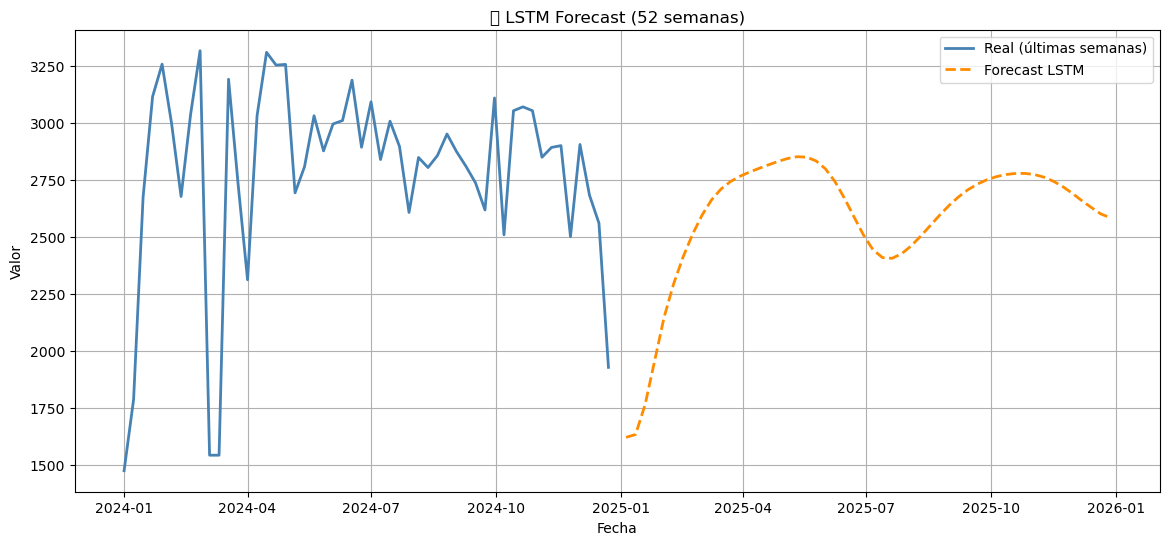

In [34]:
# Obtener la última fecha disponible en tu dataset original
last_date = df["fecha"].iloc[-1]

# Construir las fechas futuras (una por semana)
future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=LSTM_HORIZON, freq="W")

df_forecast = pd.DataFrame({
    "fecha": future_dates,
    "yhat": y_pred
})
# Valores reales de las últimas semanas
df_tail = df.tail(LSTM_HORIZON).copy()

plt.figure(figsize=(14,6))
plt.plot(df_tail["fecha"], df_tail["valor"], label="Real (últimas semanas)", linewidth=2, color="steelblue")
plt.plot(df_forecast["fecha"], df_forecast["yhat"], label="Forecast LSTM", linewidth=2, linestyle="--", color="darkorange")

plt.title("📈 LSTM Forecast ({} semanas)".format(LSTM_HORIZON))
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()



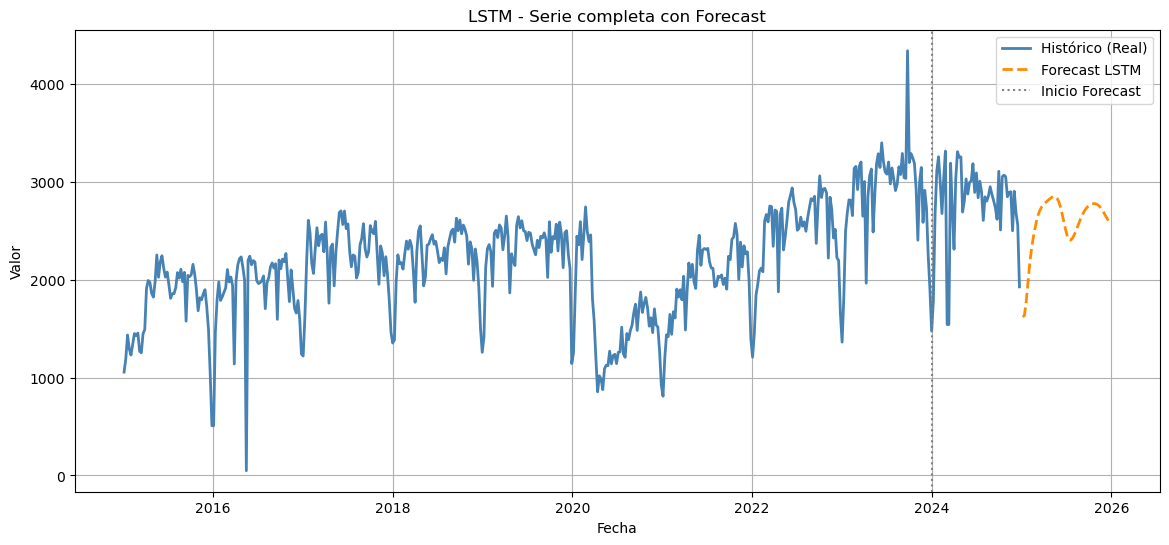

In [35]:
plt.figure(figsize=(14,6))
plt.plot(df["fecha"], df["valor"], label="Histórico (Real)", color="steelblue", linewidth=2)
plt.plot(df_forecast["fecha"], df_forecast["yhat"], label="Forecast LSTM", color="darkorange", linestyle="--", linewidth=2)

plt.axvline(df_tail["fecha"].iloc[0], color="gray", linestyle=":", label="Inicio Forecast")

plt.title("LSTM - Serie completa con Forecast")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()
